# Figure 3C–D — how far apart the guide modules are

:::{important}
Run `00_BuildGuideModuleObject.ipynb` first. It writes
`outputs/adata_SingleKO_GuideModules.h5ad`, which this notebook reads for the
per-cell guide-module indicators `M1` … `M6` and `CONTROL`.
:::

Restricted to the three largest clusters, this notebook embeds the cells with a
*supervised* UMAP that is told which module each cell belongs to (3C), and then
measures the optimal-transport distance between every pair of modules (3D).

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import ot
import pandas as pd
import scanpy as sc
import scipy.stats
import seaborn as sns
import umap

%matplotlib inline

sc.set_figure_params(dpi=100, fontsize=12)
sc.settings.verbosity = "hint"

In [2]:
E3LIGASE = Path("/home/eraslab1/Projects/E3Ligase/analysisSingle")
INPUT_H5AD     = Path("outputs/adata_SingleKO_GuideModules.h5ad")
DC_STATE_GENES = E3LIGASE / "TextFiles/PositiveControls/DC_cellstate_genes.csv"

FIGURE_DIR = Path("figures"); FIGURE_DIR.mkdir(exist_ok=True)

CLUSTERS_KEPT = ["0", "1", "2"]     # the three largest clusters
UMAP_NEIGHBORS = 18
RANDOM_SEED = 0                     # the embedding and the OT sampling are random

# group column -> label, and the integer code used to colour the embedding.
# The original relied on LabelEncoder assigning these codes by alphabetical
# order of the one-hot strings; they are written out here instead.
GROUPS = ["CONTROL", "M1", "M2", "M3", "M4", "M5", "M6"]
CLASSES = GROUPS                     # index == the code used to colour the embedding

# colours for the 3C embedding
MODULE_COLORS = {"CONTROL": "#1f77b4",   # blue
                 "M1": "#d62728",        # red
                 "M2": "#17becf",        # cyan
                 "M3": "#32cd32",        # lime green
                 "M4": "#ff7f0e",        # orange
                 "M5": "#8c564b",        # brown
                 "M6": "#e377c2"}        # pink

# row/column order of the 3D distance matrix
DISTANCE_ORDER = ["CONTROL", "M2", "M3", "M6", "M5", "M1", "M4"]

# optimal transport
OT_SAMPLE_SIZE = 300     # cells drawn per group per replicate
OT_REPLICATES  = 100     # replicates averaged per pair

## Load, score the cell states, and keep the three main clusters

In [3]:
adata = sc.read(INPUT_H5AD)

dcGenes = pd.read_csv(DC_STATE_GENES)
macGenes = dcGenes["Macrophage genes"].unique()
allDCgenes = np.concatenate(
    [dcGenes["DC1 genes"].unique(), dcGenes["DC2 genes"].unique(), dcGenes["mregDC genes"].unique()]
)

sc.tl.score_genes(adata=adata, gene_list=macGenes, score_name="Mac")
sc.tl.score_genes(adata=adata, gene_list=allDCgenes, score_name="DCSig")
adata.obs["DCSig_zscore"] = scipy.stats.zscore(adata.obs["DCSig"])
adata.obs["Mac_zscore"] = scipy.stats.zscore(adata.obs["Mac"])
adata.obs["MACoverDC"] = adata.obs["Mac_zscore"] - adata.obs["DCSig_zscore"]

adata = adata[adata.obs.leiden.isin(CLUSTERS_KEPT)].copy()   # copy: obs is written below
print(f"{adata.shape[0]} cells in clusters {CLUSTERS_KEPT}")

computing score 'Mac'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'Mac', score of gene set (adata.obs).
    1083 total control genes are used. (0:00:02)
computing score 'DCSig'


/home/eraslab1/miniconda3/lib/python3.8/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


    finished: added
    'DCSig', score of gene set (adata.obs).
    1105 total control genes are used. (0:00:02)
89169 cells in clusters ['0', '1', '2']


## Label each cell with its module

Every cell belongs to exactly one group, so the group is simply whichever
indicator column is set.

In [4]:
indicators = adata.obs[GROUPS].astype(int)
adata.obs["perCatGroups"] = indicators.idxmax(axis=1).values
adata.obs["perCat"] = adata.obs["perCatGroups"].map(CLASSES.index).values

print(adata.obs["perCatGroups"].value_counts().to_string())

CONTROL    29830
M2         17018
M3         12918
M5         12351
M6         11829
M1          3790
M4          1433


## Supervised embedding — Figure 3C

The UMAP is given the module labels, so it arranges cells by module as well as
by expression.

In [6]:
embedding = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, random_state=RANDOM_SEED).fit_transform(
    X=pd.DataFrame(adata.X), y=np.array(adata.obs["perCat"])
)
print(f"embedding: {embedding.shape}")

# UMAP has no canonical orientation: a layout is arbitrary up to rotation and
# reflection, so an unseeded rerun looks different while encoding the same
# relationships. Rotate into the frame the published figure uses - modules
# separated along y, within-module spread along x, controls at the bottom.
groupsArr = adata.obs["perCatGroups"].values
centroids = np.vstack([embedding[groupsArr == g].mean(axis=0) for g in CLASSES])
_, _, vt = np.linalg.svd(centroids - centroids.mean(axis=0))
separating = vt[0]                                      # direction between modules
rotation = np.array([[separating[1], -separating[0]],
                     [separating[0],  separating[1]]])   # sends it to +y
embedding = embedding @ rotation.T

centroidY = {g: embedding[groupsArr == g, 1].mean() for g in CLASSES}
if centroidY["CONTROL"] > centroidY["M1"]:              # controls belong at the bottom
    embedding[:, 1] *= -1
    centroidY = {g: embedding[groupsArr == g, 1].mean() for g in CLASSES}

print("module order, top to bottom:",
      [g for g, _ in sorted(centroidY.items(), key=lambda kv: -kv[1])])
print(f"x range: {embedding[:,0].min():.2f} .. {embedding[:,0].max():.2f}")
print(f"y range: {embedding[:,1].min():.2f} .. {embedding[:,1].max():.2f}")


embedding: (89169, 2)
module order, top to bottom: ['M5', 'M3', 'M2', 'M6', 'M1', 'M4', 'CONTROL']
x range: -10.12 .. -0.03
y range: -4.74 .. 10.75


/tmp/ipykernel_24164/3290961522.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(boundaries=np.arange(len(CLASSES) + 1) - 0.5)


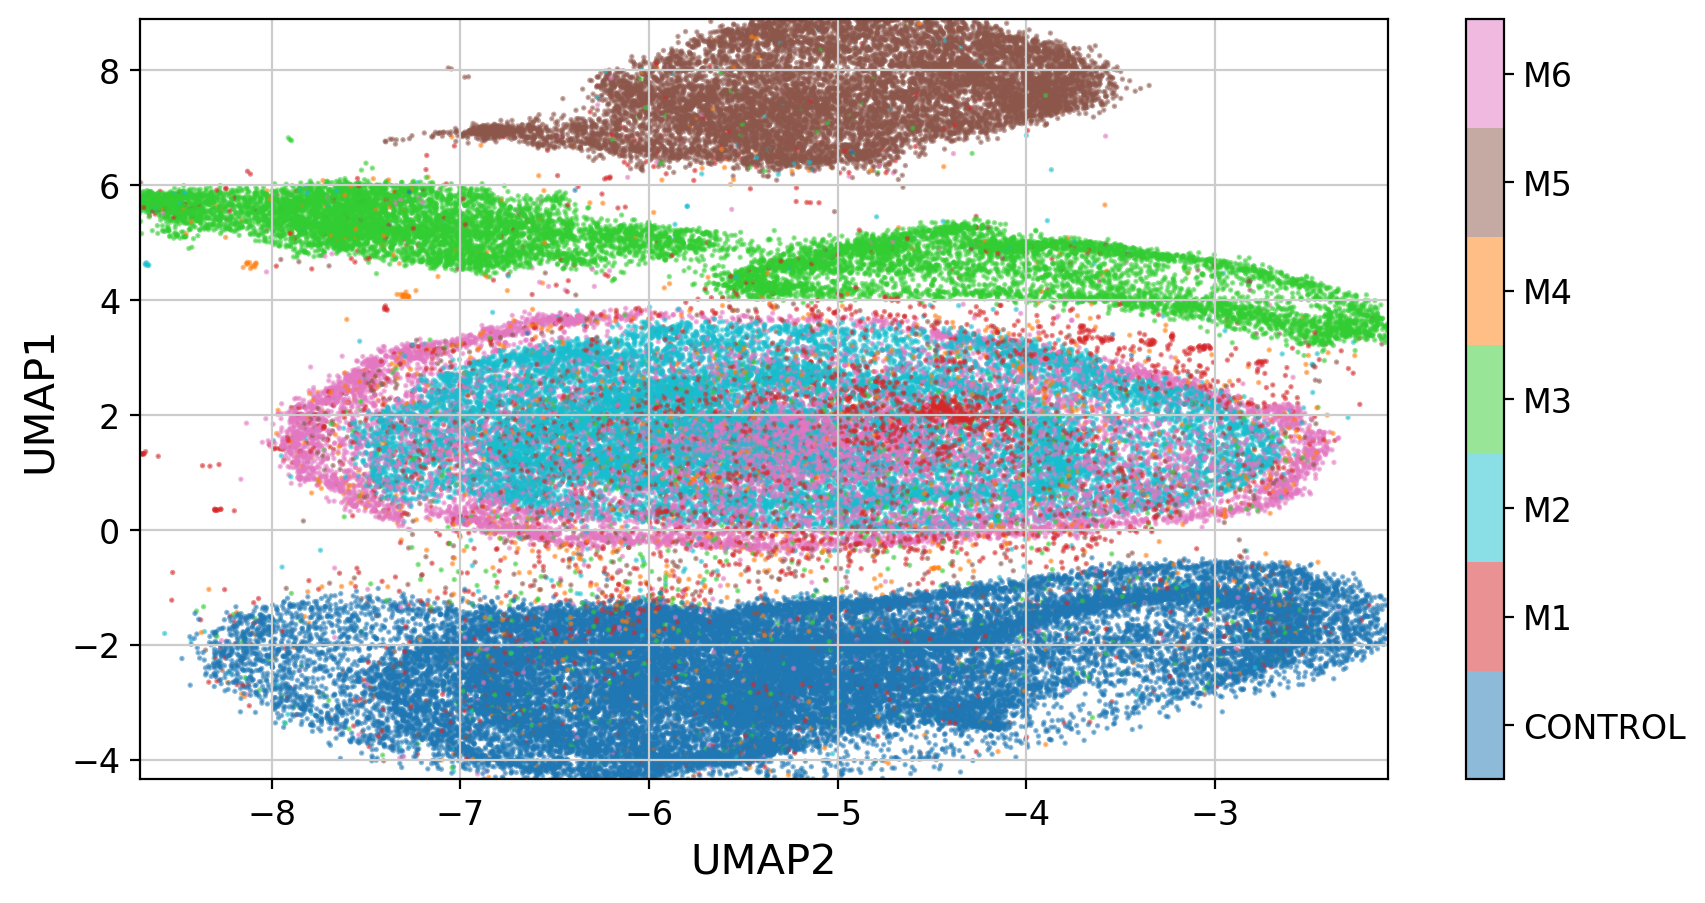

In [7]:
def scatter_embedding(colour, cmap, colourbar, filename, size):
    fig, ax = plt.subplots(1, figsize=(10, 5))
    plt.scatter(*embedding.T, s=size, c=colour, cmap=cmap, alpha=0.5)
    # limits from the data: the original hard-coded a crop of one particular
    # embedding, which does not survive recomputation
    plt.xlim(*np.percentile(embedding[:, 0], [0.1, 99.9]))
    plt.ylim(*np.percentile(embedding[:, 1], [0.1, 99.9]))
    colourbar()
    plt.xlabel("UMAP2", fontsize=15)
    plt.ylabel("UMAP1", fontsize=15)
    plt.savefig(FIGURE_DIR / filename)
    plt.show()

moduleCmap = ListedColormap([MODULE_COLORS[c] for c in CLASSES])

def module_colourbar():
    cbar = plt.colorbar(boundaries=np.arange(len(CLASSES) + 1) - 0.5)
    cbar.set_ticks(np.arange(len(CLASSES)))
    cbar.set_ticklabels(CLASSES)

scatter_embedding(adata.obs["perCat"], moduleCmap, module_colourbar, "Figure_3C.pdf", size=0.9)

The same embedding coloured by the macrophage-over-dendritic score.

/tmp/ipykernel_18169/3896602392.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  lambda: plt.colorbar(), "Figure_3C_supplement.pdf", size=2,


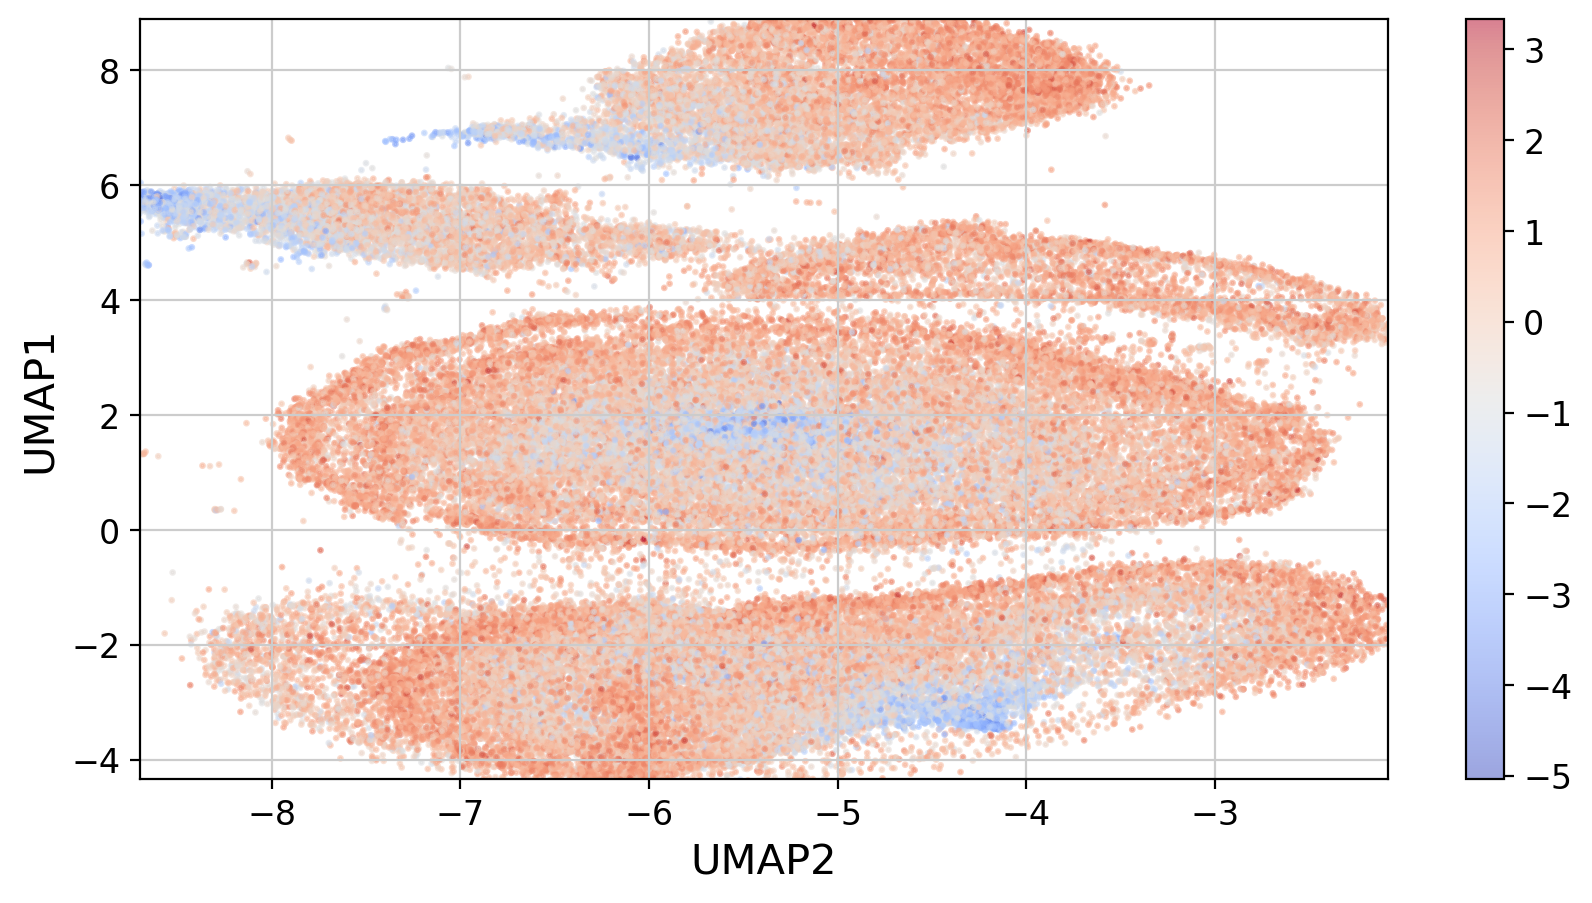

In [8]:
scatter_embedding(
    adata.obs["MACoverDC"], "coolwarm",
    lambda: plt.colorbar(), "Figure_3C_supplement.pdf", size=2,
)

## Distance between modules — Figure 3D

The optimal-transport distance between two groups is averaged over repeated
random subsamples, since it is computed on a sample of cells rather than all of
them.

:::{note}
`inDat`, the matrix these distances are computed on, was not defined in the
archived notebook. The live copy in the analysis tree defines it as
`inDat = adata.X.copy()`, the expression matrix, which is what is used here.
:::

In [9]:
def ot_distance(exp1, exp2, rng, n=None):
    if n is not None:
        exp1 = exp1[rng.choice(exp1.shape[0], n, replace=False), :]
        exp2 = exp2[rng.choice(exp2.shape[0], n, replace=False), :]
    cost = ot.dist(exp1, exp2)
    weights1 = np.ones(len(exp1)) / len(exp1)
    weights2 = np.ones(len(exp2)) / len(exp2)
    return ot.emd2(weights1, weights2, cost)

inDat = np.asarray(adata.X)
groups = adata.obs["perCatGroups"].values
rng = np.random.default_rng(RANDOM_SEED)

real_dist_mat = pd.DataFrame(np.zeros((len(DISTANCE_ORDER), len(DISTANCE_ORDER))),
                             index=DISTANCE_ORDER, columns=DISTANCE_ORDER)
for i, first in enumerate(DISTANCE_ORDER):
    for second in DISTANCE_ORDER[i:]:
        x, y = inDat[groups == first], inDat[groups == second]
        distances = [ot_distance(x, y, rng, n=OT_SAMPLE_SIZE) for _ in range(OT_REPLICATES)]
        real_dist_mat.loc[first, second] = np.round(float(np.mean(distances)), -1)

real_dist_mat

,CONTROL,M2,M3,M6,M5,M1,M4
CONTROL,1700.0,1740.0,1730.0,1720.0,1720.0,1770.0,1780.0
M2,0.0,1730.0,1750.0,1740.0,1750.0,1780.0,1800.0
M3,0.0,0.0,1690.0,1730.0,1730.0,1780.0,1790.0
M6,0.0,0.0,0.0,1670.0,1720.0,1770.0,1780.0
M5,0.0,0.0,0.0,0.0,1670.0,1770.0,1780.0
M1,0.0,0.0,0.0,0.0,0.0,1660.0,1830.0
M4,0.0,0.0,0.0,0.0,0.0,0.0,1440.0


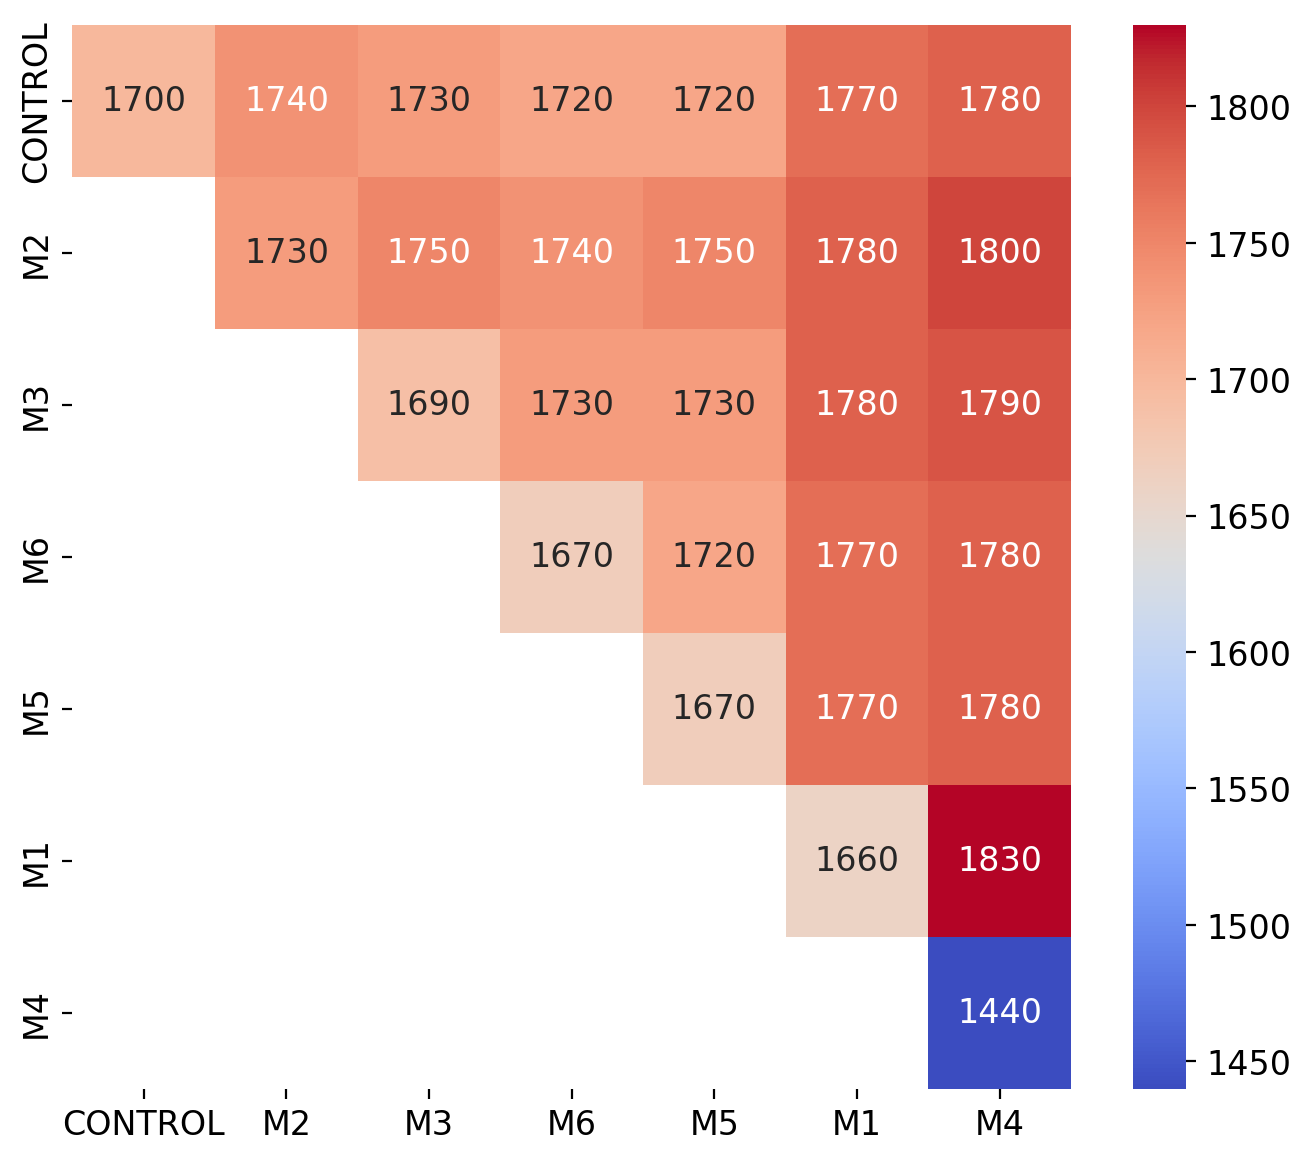

In [10]:
plt.figure(figsize=(8, 7))
mask = np.zeros_like(real_dist_mat)
mask[np.tril_indices_from(mask, k=-1)] = True
sns.heatmap(real_dist_mat, annot=True, mask=mask, cmap="coolwarm", fmt=".0f")
plt.savefig(FIGURE_DIR / "Figure_3D.pdf")
plt.show()